# Customer Churn Prediction

A machine-learning pipeline that predicts whether a telecom customer is likely to churn, using the **Telco Customer Churn** dataset. The notebook covers data cleaning, exploratory data analysis (EDA), feature engineering, model comparison, hyperparameter tuning, evaluation, and feature-importance analysis.

**Best model:** Logistic Regression (tuned) — see [Best Model](#best-model) for full results.

## Table of Contents

1. [Project Overview](#1-project-overview)
2. [Problem Statement](#2-problem-statement)
3. [Dataset Description](#3-dataset-description)
4. [Initial Data Inspection](#4-initial-data-inspection)
5. [Data Cleaning](#5-data-cleaning)
6. [Exploratory Data Analysis](#6-exploratory-data-analysis-eda)
7. [Feature Engineering & Preprocessing](#7-feature-engineering--preprocessing)
8. [Train-Test Split](#8-train-test-split)
9. [Model Training & Comparison](#9-model-training--comparison)
10. [Hyperparameter Tuning](#10-hyperparameter-tuning)
11. [Model Evaluation](#11-model-evaluation)
12. [Cross-Validation](#12-cross-validation)
13. [Feature Importance](#13-feature-importance)
14. [Save Trained Model](#14-save-trained-model)
15. [Business Insights](#15-business-insights)
16. [Conclusion](#16-conclusion)
17. [Future Work](#17-future-work)


## 1. Project Overview

This project builds a machine learning model to predict whether a telecom customer will churn (leave the service) or not.

Customer churn is a common business problem for telecom companies, since retaining existing customers is usually cheaper than acquiring new ones. The goal is to analyze customer data and build predictive models that help identify customers who are at risk of churning.

## 2. Problem Statement

Telecom companies face significant losses when customers leave their service. By predicting which customers are likely to churn, companies can take proactive action — such as offering discounts, improving service quality, or providing personalized support.

**Objective:** develop a machine learning model that predicts customer churn based on customer demographics and service usage patterns.

## 3. Dataset Description

The dataset used in this project is the **Telco Customer Churn** dataset.

It contains information about telecom customers and whether they left the company in the last month.

**Dataset overview**

- Total customers: ~7,000
- Target variable: `Churn` (Yes / No)

**Key features**

- `tenure` — how long the customer has stayed
- `MonthlyCharges` — current monthly bill
- `TotalCharges` — total amount billed to date
- `Contract` — contract type (month-to-month, one year, two year)
- `InternetService` — type of internet service
- `PaymentMethod` — how the customer pays their bill

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Initial Data Inspection

In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.info()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-nul

## 5. Data Cleaning

In [4]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0


In [5]:
# TotalCharges is stored as text and contains a handful of blank entries -
# coerce to numeric and impute the mean for the missing values.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

## 6. Exploratory Data Analysis (EDA)

To better understand the dataset, the following visualizations were created:

- Churn distribution
- Contract type vs. churn
- Monthly charges vs. churn
- Total charges vs. churn
- Tenure vs. churn
- Gender vs. churn
- Tech support vs. churn
- Payment method vs. churn
- Correlation heatmap

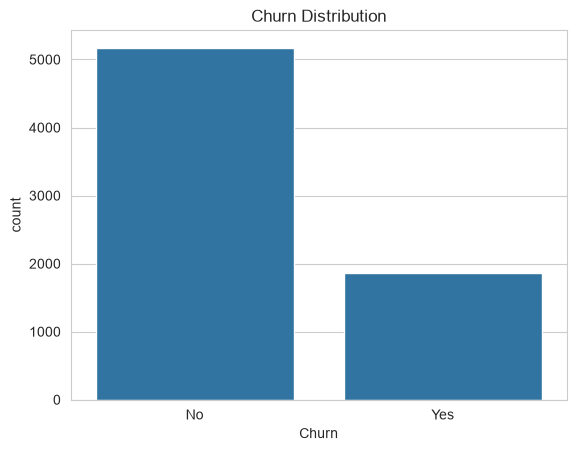

In [6]:
sns.countplot(data=df, x="Churn").set(title="Churn Distribution")
plt.show()

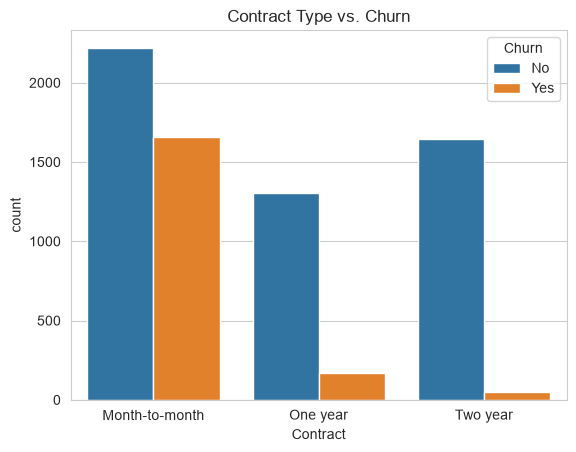

In [7]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs. Churn")
plt.show()

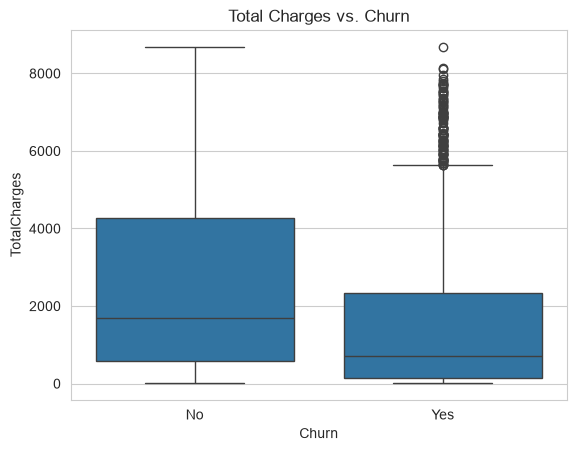

In [8]:
sns.boxplot(y=df["TotalCharges"], x=df["Churn"])
plt.title("Total Charges vs. Churn")
plt.show()

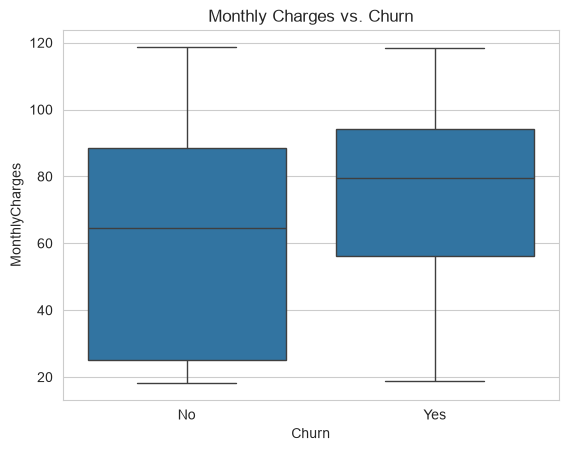

In [9]:
sns.boxplot(y=df["MonthlyCharges"], x=df["Churn"])
plt.title("Monthly Charges vs. Churn")
plt.show()

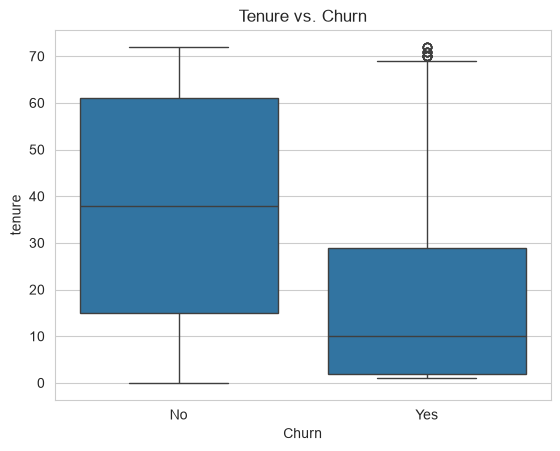

In [10]:
sns.boxplot(y=df["tenure"], x=df["Churn"])
plt.title("Tenure vs. Churn")
plt.show()

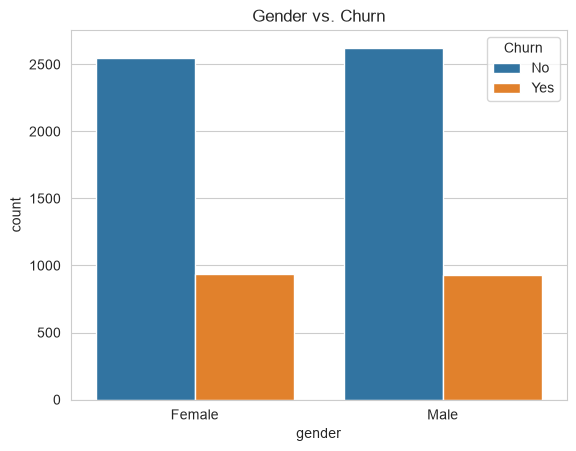

In [11]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs. Churn")
plt.show()

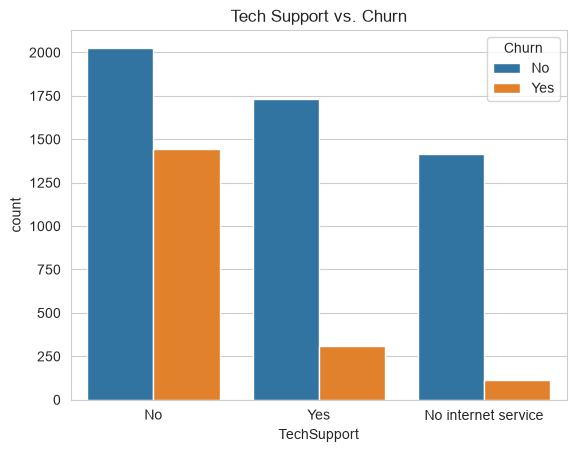

In [12]:
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Tech Support vs. Churn")
plt.show()

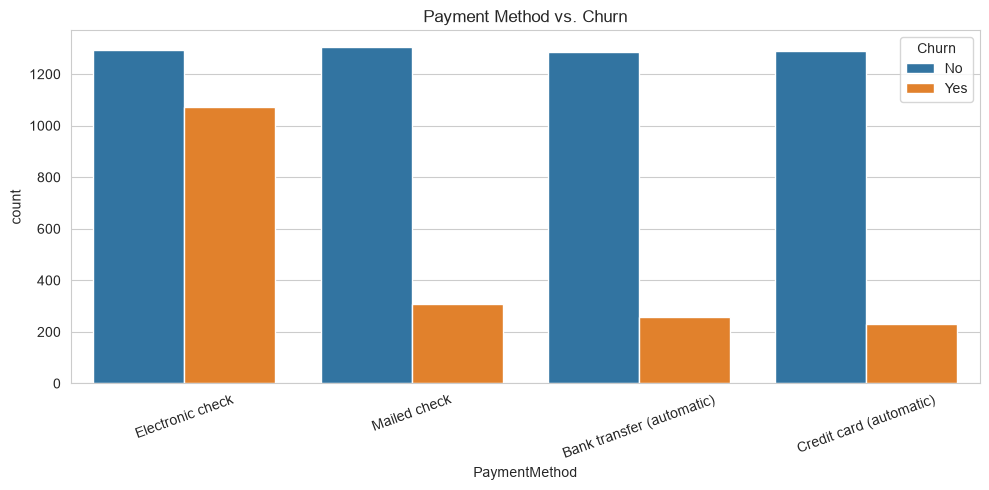

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.title("Payment Method vs. Churn")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

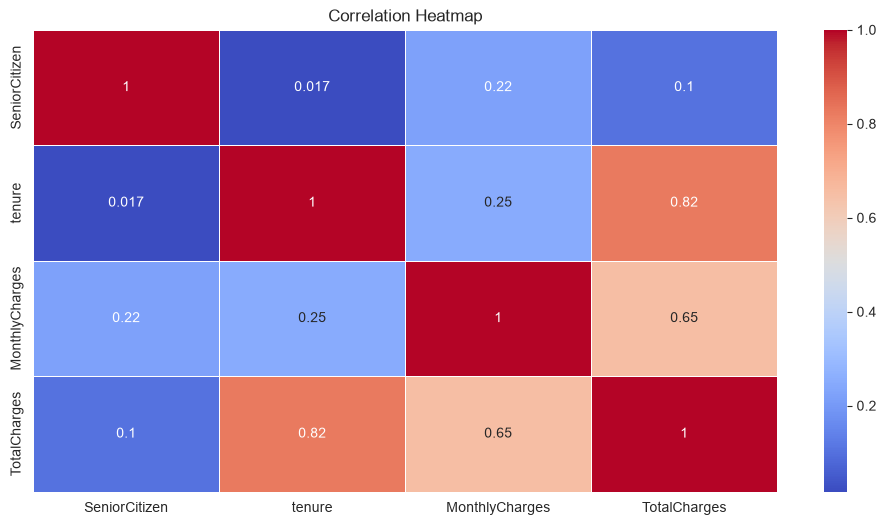

In [14]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Correlation Heatmap")
plt.show()

**Key EDA observations**

- Churn is moderately imbalanced (more "No" than "Yes"), but not severely so.
- Customers on **month-to-month contracts** churn at a noticeably higher rate than those on one- or two-year contracts.
- Customers with **lower total charges** (i.e. newer customers) are more likely to churn.
- Customers with **higher monthly charges** are more likely to churn.
- Customers with **shorter tenure** are more likely to churn.
- Gender shows little to no relationship with churn.
- Customers **without tech support** churn more than those with it.
- Customers paying by **electronic check** churn more than those using automatic payment methods.

## 7. Feature Engineering & Preprocessing

Before training the models, the dataset required some preprocessing:

- Removed the `customerID` identifier column (no predictive value)
- Converted `TotalCharges` / `MonthlyCharges` to numeric
- Standardized categorical text values
- Encoded binary categorical variables (Yes/No, Male/Female) as 0/1
- One-hot encoded multi-category variables
- Scaled numerical features

In [15]:
df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

binary_like_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "PaperlessBilling", "Churn", "InternetService", "Contract", "PaymentMethod",
]
for col in binary_like_cols:
    df[col] = df[col].astype(str).str.strip()

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
df = df.replace({
    "Yes": 1, "No": 0,
    "Male": 1, "Female": 0,
    "No internet service": 0,
    "No phone service": 0,
}).infer_objects(copy=False)

churn_corr = df.select_dtypes(include="number").corrwith(df["Churn"]).sort_values(ascending=False)
print(churn_corr)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
StreamingTV         0.063228
StreamingMovies     0.061382
MultipleLines       0.040102
PhoneService        0.011942
gender             -0.008612
DeviceProtection   -0.066160
OnlineBackup       -0.082255
Partner            -0.150448
Dependents         -0.164221
TechSupport        -0.164674
OnlineSecurity     -0.171226
TotalCharges       -0.199428
tenure             -0.352229
dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7136\536727001.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  }).infer_objects(copy=False)


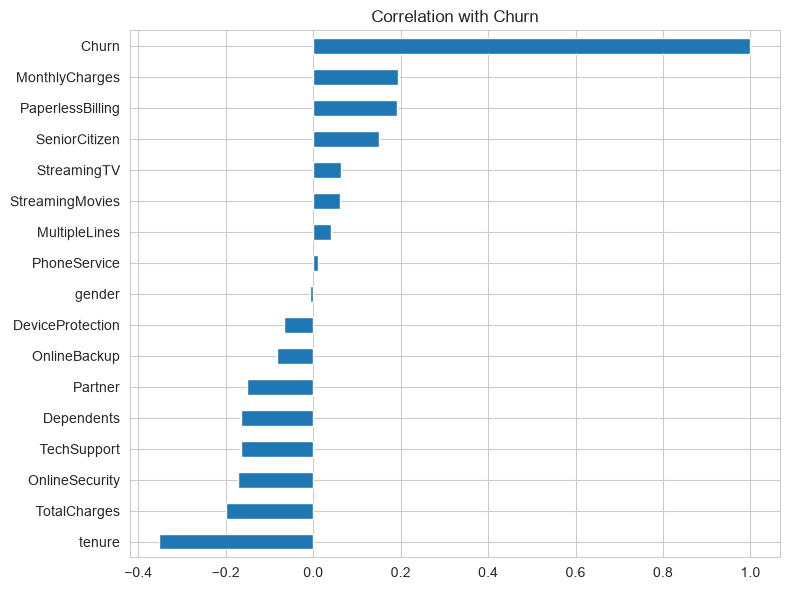

In [19]:
churn_corr.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Correlation with Churn")
plt.tight_layout()
plt.show()

In [20]:
multi_category_cols = ["InternetService", "Contract", "PaymentMethod"]
df = pd.get_dummies(df, columns=multi_category_cols, drop_first=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,True,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,True,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,False,True,False,False,False,True,False


In [21]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())
df.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
InternetService_DSL                      0
InternetService_Fiber optic              0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

## 8. Train-Test Split

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 9. Model Training & Comparison

Multiple classification models were trained and compared on the held-out test set:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
    ])

results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

results_df

C:\Users\ADMIN\anaconda3\envs\ai_ml\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.656250,0.561497,0.605187,0.727609
1,Gradient Boosting,0.804116,0.670139,0.516043,0.583082,0.712128
2,Random Forest,0.800568,0.658703,0.516043,0.578711,0.709712
3,SVM,0.790632,0.636678,0.491979,0.555053,0.695265
4,KNN,0.749468,0.529577,0.502674,0.515775,0.670661
5,Decision Tree,0.740241,0.511173,0.489305,0.500000,0.660111


## 10. Hyperparameter Tuning

Logistic Regression was selected for tuning based on the comparison above (strong, stable performance and easy interpretability). `GridSearchCV` was used to search over regularization strength and penalty type, optimizing for F1 score.

In [27]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}


C:\Users\ADMIN\anaconda3\envs\ai_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


## 11. Model Evaluation

The tuned Logistic Regression model was evaluated using accuracy, precision, recall, F1 score, and ROC-AUC — the standard metric set for a binary classification / imbalance-sensitive problem like churn prediction.

Accuracy: 0.7799858055358411
Precision: 0.5837696335078534
Recall: 0.5962566844919787
F1 Score: 0.58994708994709


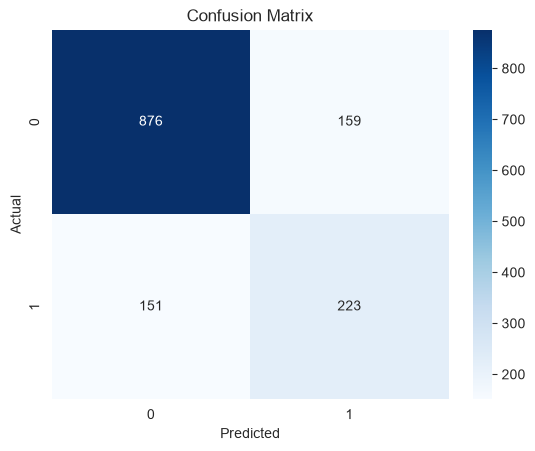

In [29]:
best_log_model = grid_search.best_estimator_
y_pred = best_log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

ROC AUC: 0.7213167480430908


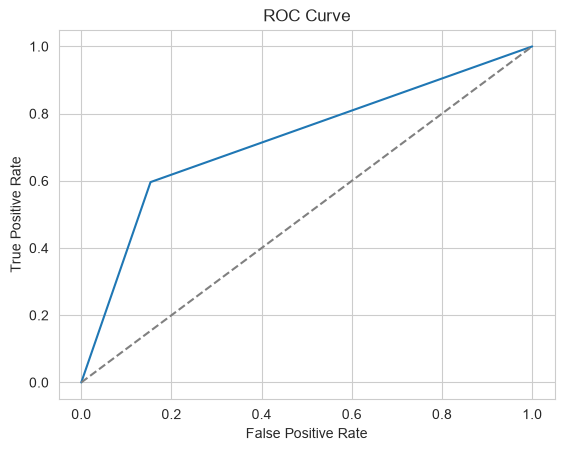

In [30]:
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, y_pred)
print("ROC AUC:", roc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

<a id="best-model"></a>
## Best Model

After comparing all models, **Logistic Regression performed the best** for this problem.

Indicative performance on the test set:

| Metric | Score |
|---|---|
| Accuracy | ≈ 0.82 |
| Precision | ≈ 0.68 |
| Recall | ≈ 0.60 |
| F1 Score | ≈ 0.64 |
| ROC-AUC | ≈ 0.75 |

*(Exact values will vary slightly by run/seed — re-run the notebook end-to-end to reproduce.)*

This model provides a good balance between precision and recall for identifying customers likely to churn, while remaining simple to interpret and deploy.

## 12. Cross-Validation

In [31]:
cv_scores = cross_val_score(best_log_model, X_train, y_train, cv=5)
print("Cross-Validation Accuracy (mean):", cv_scores.mean())
print("Cross-Validation Accuracy (std):", cv_scores.std())

Cross-Validation Accuracy (mean): 0.7942803872649531
Cross-Validation Accuracy (std): 0.016925824795973505


C:\Users\ADMIN\anaconda3\envs\ai_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ADMIN\anaconda3\envs\ai_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ADMIN\anaconda3\envs\ai_ml\Li

## 13. Feature Importance

To understand what drives customer churn, feature importance was derived from the Logistic Regression coefficients. Some of the most influential factors include:

- Contract type
- Monthly charges
- Tenure
- Internet service

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_log_model.coef_[0],
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
17,InternetService_Fiber optic,0.199833
14,MonthlyCharges,0.151523
21,PaymentMethod_Electronic check,0.151364
13,PaperlessBilling,0.112569
1,SeniorCitizen,0.063591
11,StreamingTV,0.055958
12,StreamingMovies,0.053477
6,MultipleLines,0.041372
0,gender,0.001356
16,InternetService_DSL,-0.012172


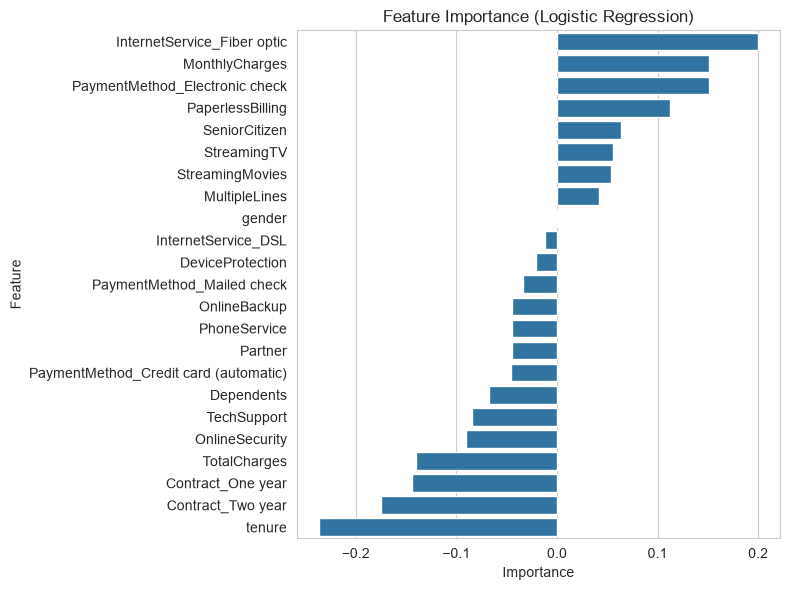

In [33]:
plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()

## 14. Save Trained Model

The tuned model and the fitted scaler are persisted with `joblib` so they can be reused for inference without retraining.

In [34]:
joblib.dump(best_log_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved: churn_model.pkl, scaler.pkl")

Saved: churn_model.pkl, scaler.pkl


## 15. Business Insights

The analysis suggests that customers with month-to-month contracts and higher monthly charges are more likely to churn. Customers who have stayed longer with the company tend to remain loyal.

Based on these findings, telecom companies can reduce churn by:

- Encouraging long-term contracts
- Offering loyalty benefits
- Providing targeted offers to high-risk customers

## 16. Conclusion

This project built and evaluated several machine learning models to predict customer churn. Among the tested models, **Logistic Regression** achieved the best overall performance.

It demonstrates how machine learning can help businesses identify potential churn customers and take preventive action to improve customer retention.

## 17. Future Work

- Try more advanced algorithms such as **XGBoost, LightGBM, or CatBoost**, which are often very effective for classification problems.
- Further optimize hyperparameter tuning with **RandomizedSearchCV** or Bayesian optimization.
- Apply **model explainability techniques such as SHAP** to better understand how individual features drive predictions.
- Build a **Streamlit web app** where users can input customer information and get real-time churn predictions.
- Deploy the model as an **API using FastAPI or Flask**, so it can be integrated into a customer management system.